# Temperature comparison for ensemble-pooled refinement

This paired experiment tests lower stochastic-search temperatures of 0.005
and 0.001 from the same no-holdout five-member forward-knee initialization.
Each run uses a 500-step maximum, convergence patience of 50, cooling rate
0.97, and the original SVM parameter grid. Existing temperature-0.05 results
are included for context without rerunning them.

In [1]:
from pathlib import Path
import copy
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "mistic" / "svmSet.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svc, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

Matplotlib is building the font cache; this may take a moment.


## Fixed experimental design

- 500 observations and 100 predictors: 10 informative, 10 redundant, and 80 noise.
- One stratified 25% blind set, withheld before every preprocessing and modeling step.
- Three inner seeds and exactly five SVM-set members.
- Fifteen percent of the outer-training rows are reserved for ensemble-level validation and excluded from all member CV splits.
- `combined_rank(weight=0.75)`, separate feature sets, and separate parameters.
- Forward search uses the 20-medoid singleton screen and a 20-feature maximum.
- Backward search uses scaled gamma during search and final full-grid retuning.
- Greedy selection returns the knee-selected subset before refinement.
- Stochastic variants start from identical deep copies of that subset. Every iteration budget uses the same seed. Both single-model proposals and joint all-model proposals are tested.
- Each sklearn unified-feature reference uses only the top `knee_feature_count`
  features according to the corresponding ensemble's unified rank.

In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))

X_values, y_values = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_repeated=0,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.0,
    flip_y=0.03,
    shuffle=False,
    random_state=2026,
)
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="class")

MODEL_COUNTS = [5]
REFINEMENT_STEPS = [0, 10, 20, 50, 100]
SELECTION_STRATEGIES = ["forward_knee", "backward_knee"]
INNER_SEEDS = list(range(3))
BLIND_SET_SEED = 42
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
ENSEMBLE_VALIDATION_SIZE = 0.0
RANK_WEIGHT = 0.75
FORWARD_MAX_FEATURES = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]

X_train, X_blind, y_train, y_blind = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=BLIND_SET_SEED
)
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")

Training rows: 375; fixed blind rows: 125


In [3]:
def parameter_grid():
    return [
        paramSet(model={"C": cost}, kernel={"gamma": gamma})
        for cost in C_VALUES for gamma in GAMMA_VALUES
    ]


def metric_row(y_true, predictions, decision_values):
    return {
        "roc_auc": roc_auc_score(y_true, decision_values),
        "f1": f1_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "accuracy": accuracy_score(y_true, predictions),
    }


def fit_sklearn_reference(X_train_subset, y_train, seed):
    pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("svc", SVC(kernel="rbf", class_weight="balanced")),
    ])
    search = GridSearchCV(
        pipeline,
        {"svc__C": C_VALUES, "svc__gamma": GAMMA_VALUES},
        scoring="roc_auc",
        cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1,
        refit=True,
    )
    return search.fit(X_train_subset, y_train)


def fit_knee_ensemble(strategy, num_models, seed):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(
        X_scaled,
        np.asarray(y_train),
        num_feature_medoids=20,
        ensemble_validation_size=ENSEMBLE_VALIDATION_SIZE,
        ensemble_validation_random_seed=50_000,
        ensemble_validation_stratify=True,
    )
    splits.classification(
        num_sets=num_models,
        validation_size=INNER_VALIDATION_SIZE,
        random_seed=seed,
    )
    ensemble = svmSet(
        SVC(kernel="precomputed", class_weight="balanced"),
        splits,
        score_method=score_svc(weight=1.0).score,
        kernel=kernelWrapper(type="rbf"),
        separate_feature_sets=True,
        separate_parameters=True,
    )
    options = dict(
        parameter_grid=parameter_grid(),
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample",
        tune_models_each_step=False,
        post_find_knee=True,
    )
    if strategy == "forward_knee":
        ensemble.greedy_forward_selection(
            reduction_factor=0,
            max_features=FORWARD_MAX_FEATURES,
            **options,
        )
    else:
        ensemble.greedy_backward_selection(reduction_factor=0.1, **options)
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified_set = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([
        feature for feature in ensemble.unified_sorted_features
        if feature in unified_set
    ], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), 1 - signal_count / len(features)


def ensemble_row(ensemble, scaler, seed, strategy, num_models, steps, knee_count, update_all_models):
    X_blind_scaled = scaler.transform(X_blind)
    predictions = ensemble.predict(X_blind_scaled)
    decisions = ensemble.decision_function(X_blind_scaled)
    unified = np.asarray(ensemble.unified_features, dtype=int)
    top20 = ranked_unified_features(ensemble, 20)
    signal_recall, noise_fraction = recovery(top20)
    member_predictions = np.column_stack([
        ensemble.predict(X_blind_scaled, model_index=i) for i in range(num_models)
    ])
    disagreement = np.mean([
        np.mean(member_predictions[:, i] != member_predictions[:, j])
        for i in range(num_models) for j in range(i + 1, num_models)
    ]) if num_models > 1 else 0.0
    history = getattr(ensemble, "stochastic_performance_", [])
    return {
        "seed": seed,
        "method": "MiSTIC SVM set",
        "selection_strategy": strategy,
        "refinement_steps": steps,
        "update_all_models": update_all_models,
        "refinement_objective": "ensemble_validation" if steps else "knee_baseline",
        "num_models": num_models,
        "knee_feature_count": knee_count,
        "num_unified_features": len(unified),
        "signal_recall": signal_recall,
        "noise_fraction": noise_fraction,
        "member_disagreement": disagreement,
        "accepted_moves": sum(row.accepted for row in history),
        **metric_row(y_blind, predictions, decisions),
    }


def reference_row(ensemble, seed, strategy, num_models, steps, knee_count, update_all_models):
    features = ranked_unified_features(ensemble, knee_count)
    signal_recall, noise_fraction = recovery(features)
    reference = fit_sklearn_reference(X_train.iloc[:, features], y_train, seed)
    return {
        "seed": seed,
        "method": "sklearn on knee-ranked unified features",
        "selection_strategy": strategy,
        "refinement_steps": steps,
        "update_all_models": update_all_models,
        "refinement_objective": "ensemble_validation" if steps else "knee_baseline",
        "num_models": num_models,
        "knee_feature_count": knee_count,
        "num_unified_features": len(features),
        "signal_recall": signal_recall,
        "noise_fraction": noise_fraction,
        "member_disagreement": 0.0,
        "accepted_moves": np.nan,
        **metric_row(
            y_blind,
            reference.predict(X_blind.iloc[:, features]),
            reference.decision_function(X_blind.iloc[:, features]),
        ),
    }

## Run the comparison

For each seed and selection direction, the two refined conditions begin from
independent copies of the same knee-selected ensemble. Refinement retunes every
proposal with the same parameter grid used by the greedy search.

In [4]:
rows = []
history_rows = []
strategy = "forward_knee"
num_models = 5
max_steps = 500
temperatures = [0.005, 0.001]
for seed in INNER_SEEDS:
    scaler, base_ensemble, knee_count = fit_knee_ensemble(
        strategy, num_models, seed
    )
    rows.append(ensemble_row(
        base_ensemble, scaler, seed, strategy, num_models, 0, knee_count, False,
    ))
    rows[-1].update({
        "method": "No-holdout forward-knee baseline",
        "temperature": np.nan,
        "search_max_steps": 0,
        "iterations_run": 0,
        "converged": False,
        "stop_reason": "not_run",
        "search_best_score": np.nan,
    })

    for temperature in temperatures:
        candidate = copy.deepcopy(base_ensemble)
        candidate.ensemble_stochastic_feature_selection(
            parameter_grid(),
            n_iterations=max_steps,
            temperature=temperature,
            cooling_rate=0.97,
            add_probability=0.5,
            random_seed=10_000 + 100 * num_models + seed,
            convergence_patience=50,
        )
        rows.append(ensemble_row(
            candidate, scaler, seed, strategy, num_models,
            candidate.ensemble_stochastic_iterations_, knee_count, False,
        ))
        rows[-1].update({
            "method": f"No-holdout pooled search, T={temperature}",
            "temperature": temperature,
            "search_max_steps": max_steps,
            "iterations_run": candidate.ensemble_stochastic_iterations_,
            "converged": candidate.ensemble_stochastic_converged_,
            "stop_reason": candidate.ensemble_stochastic_stop_reason_,
            "search_best_score": candidate.ensemble_stochastic_best_score_,
            "accepted_moves": sum(
                record.accepted
                for record in candidate.ensemble_stochastic_performance_
            ),
        })
        running_best = -np.inf
        for record in candidate.ensemble_stochastic_performance_:
            if record.accepted:
                running_best = max(running_best, record.score)
            history_rows.append({
                "seed": seed,
                "temperature_setting": temperature,
                "step": record.iteration + 1,
                "estimated_score": record.estimated_score,
                "actual_score": record.score,
                "accepted": record.accepted,
                "best_accepted_proposal_score": (
                    running_best if np.isfinite(running_best) else np.nan
                ),
                "pool_size": record.pool_size,
                "annealed_temperature": record.temperature,
            })
        print(
            f"completed seed={seed}; T={temperature}; "
            f"iterations={candidate.ensemble_stochastic_iterations_}; "
            f"stop={candidate.ensemble_stochastic_stop_reason_}"
        )

temperature_results = pd.DataFrame(rows)
temperature_history = pd.DataFrame(history_rows)
temperature_results.to_csv(
    repo_root / "validation/Synthetic100_svmSet_forward_ensemble_pooled_temperature_no_holdout_results.csv",
    index=False,
)
temperature_history.to_csv(
    repo_root / "validation/Synthetic100_svmSet_forward_ensemble_pooled_temperature_no_holdout_history.csv",
    index=False,
)
temperature_results

Number of Features: 1, Score: 0.698


Number of Features: 2, Score: 0.751


Number of Features: 3, Score: 0.778


Number of Features: 4, Score: 0.767


Number of Features: 5, Score: 0.762


...

Number of Features: 19, Score: 0.744


Number of Features: 20, Score: 0.735
Number of Features: 100, Score: 0.703


completed seed=2; T=0.005; iterations=500; stop=max_iterations


completed seed=2; T=0.001; iterations=500; stop=max_iterations


,seed,method,selection_strategy,refinement_steps,update_all_models,refinement_objective,num_models,knee_feature_count,num_unified_features,signal_recall,...,roc_auc,f1,balanced_accuracy,accuracy,temperature,search_max_steps,iterations_run,converged,stop_reason,search_best_score
0,0,No-holdout forward-knee baseline,forward_knee,0,False,knee_baseline,5,16,36,0.55,...,0.950052,0.873950,0.884576,0.880,NaN,0,0,False,not_run,NaN
1,0,"No-holdout pooled search, T=0.005",forward_knee,500,False,ensemble_validation,5,16,60,0.60,...,0.952381,0.849558,0.863354,0.864,0.005,500,500,False,max_iterations,0.986463
2,0,"No-holdout pooled search, T=0.001",forward_knee,457,False,ensemble_validation,5,16,62,0.60,...,0.943841,0.872727,0.885093,0.888,0.001,500,457,True,converged,0.986939
3,1,No-holdout forward-knee baseline,forward_knee,0,False,knee_baseline,5,12,24,0.65,...,0.964803,0.882883,0.894022,0.896,NaN,0,0,False,not_run,NaN
4,1,"No-holdout pooled search, T=0.005",forward_knee,500,False,ensemble_validation,5,12,60,0.60,...,0.960663,0.864865,0.877847,0.880,0.005,500,500,False,max_iterations,0.982995
5,1,"No-holdout pooled search, T=0.001",forward_knee,493,False,ensemble_validation,5,12,46,0.65,...,0.969979,0.877193,0.888458,0.888,0.001,500,493,True,converged,0.986860
6,2,No-holdout forward-knee baseline,forward_knee,0,False,knee_baseline,5,5,14,0.50,...,0.934783,0.832000,0.841097,0.832,NaN,0,0,False,not_run,NaN
7,2,"No-holdout pooled search, T=0.005",forward_knee,500,False,ensemble_validation,5,5,47,0.60,...,0.919513,0.807339,0.827640,0.832,0.005,500,500,False,max_iterations,0.961399
8,2,"No-holdout pooled search, T=0.001",forward_knee,500,False,ensemble_validation,5,5,51,0.60,...,0.935300,0.857143,0.870600,0.872,0.001,500,500,False,max_iterations,0.946077


## Blind-set comparison

The two lower-temperature searches are compared with their paired zero-step
baseline and the existing otherwise-identical temperature-0.05 search.

In [5]:
existing = pd.read_csv(
    repo_root / "validation/Synthetic100_svmSet_forward_ensemble_pooled_search_no_holdout_results.csv"
).query("method == 'No-holdout ensemble-pooled search'").copy()
existing["method"] = "No-holdout pooled search, T=0.05"
existing["temperature"] = 0.05

comparison = pd.concat([temperature_results, existing], ignore_index=True)
comparison.groupby("method").agg(
    mean_auc=("roc_auc", "mean"),
    sd_auc=("roc_auc", "std"),
    mean_f1=("f1", "mean"),
    mean_accuracy=("accuracy", "mean"),
    mean_signal_recall=("signal_recall", "mean"),
    mean_signal_precision=("noise_fraction", lambda x: 1 - x.mean()),
    mean_disagreement=("member_disagreement", "mean"),
    mean_union_size=("num_unified_features", "mean"),
    mean_iterations=("iterations_run", "mean"),
    mean_accepted=("accepted_moves", "mean"),
).round(4)

,mean_auc,sd_auc,mean_f1,mean_accuracy,mean_signal_recall,mean_signal_precision,mean_disagreement,mean_union_size,mean_iterations,mean_accepted
method,,,,,,,,,,
No-holdout forward-knee baseline,0.9499,0.0150,0.8629,0.8693,0.5667,0.6381,0.1669,24.6667,0.0000,0.0000
"No-holdout pooled search, T=0.001",0.9497,0.0181,0.8690,0.8827,0.6167,0.6167,0.2245,53.0000,483.3333,87.6667
"No-holdout pooled search, T=0.005",0.9442,0.0218,0.8406,0.8587,0.6000,0.6000,0.2208,55.6667,500.0000,124.6667
"No-holdout pooled search, T=0.05",0.9521,0.0124,0.8630,0.8720,0.5667,0.5667,0.2107,29.0000,68.6667,62.3333


In [6]:
base = temperature_results.query(
    "method == 'No-holdout forward-knee baseline'"
).set_index("seed")
paired_rows = []
for temperature in temperatures:
    refined = temperature_results.query(
        "temperature == @temperature"
    ).set_index("seed")
    for seed in INNER_SEEDS:
        paired_rows.append({
            "temperature": temperature,
            "seed": seed,
            "delta_auc": refined.loc[seed, "roc_auc"] - base.loc[seed, "roc_auc"],
            "delta_f1": refined.loc[seed, "f1"] - base.loc[seed, "f1"],
            "delta_accuracy": refined.loc[seed, "accuracy"] - base.loc[seed, "accuracy"],
            "delta_signal_recall": refined.loc[seed, "signal_recall"] - base.loc[seed, "signal_recall"],
            "iterations": refined.loc[seed, "iterations_run"],
            "acceptance_rate": refined.loc[seed, "accepted_moves"] / refined.loc[seed, "iterations_run"],
        })
paired = pd.DataFrame(paired_rows)
paired.groupby("temperature").agg(
    mean_delta_auc=("delta_auc", "mean"),
    mean_delta_f1=("delta_f1", "mean"),
    mean_delta_accuracy=("delta_accuracy", "mean"),
    mean_delta_signal_recall=("delta_signal_recall", "mean"),
    mean_iterations=("iterations", "mean"),
    mean_acceptance_rate=("acceptance_rate", "mean"),
).round(4)

,mean_delta_auc,mean_delta_f1,mean_delta_accuracy,mean_delta_signal_recall,mean_iterations,mean_acceptance_rate
temperature,,,,,,
0.001,-0.0002,0.0061,0.0133,0.0500,483.3333,0.1823
0.005,-0.0057,-0.0224,-0.0107,0.0333,500.0000,0.2493


## Search trajectories

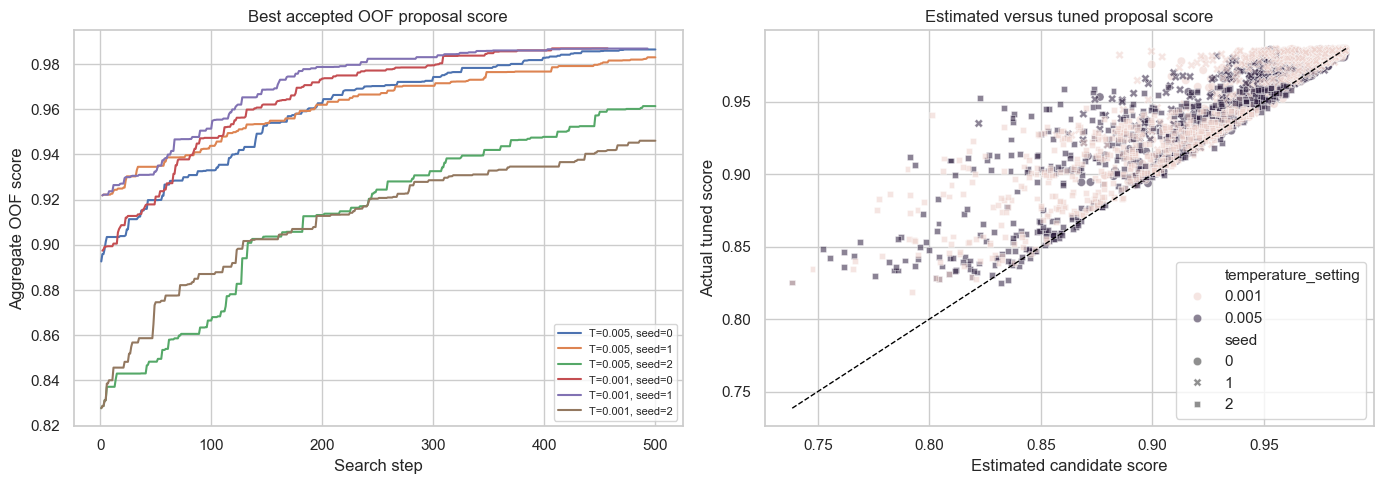

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for temperature in temperatures:
    for seed in INNER_SEEDS:
        values = temperature_history.query(
            "temperature_setting == @temperature and seed == @seed"
        )
        axes[0].plot(
            values["step"], values["best_accepted_proposal_score"],
            label=f"T={temperature}, seed={seed}",
        )
axes[0].set(
    title="Best accepted OOF proposal score",
    xlabel="Search step", ylabel="Aggregate OOF score",
)
axes[0].legend(fontsize=8)

sns.scatterplot(
    data=temperature_history, x="estimated_score", y="actual_score",
    hue="temperature_setting", style="seed", alpha=0.55, ax=axes[1],
)
limits = [
    min(temperature_history["estimated_score"].min(), temperature_history["actual_score"].min()),
    max(temperature_history["estimated_score"].max(), temperature_history["actual_score"].max()),
]
axes[1].plot(limits, limits, color="black", linestyle="--", linewidth=1)
axes[1].set(
    title="Estimated versus tuned proposal score",
    xlabel="Estimated candidate score", ylabel="Actual tuned score",
)
plt.tight_layout()